<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CuPy_for_Terrabyte_Level_Cache_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

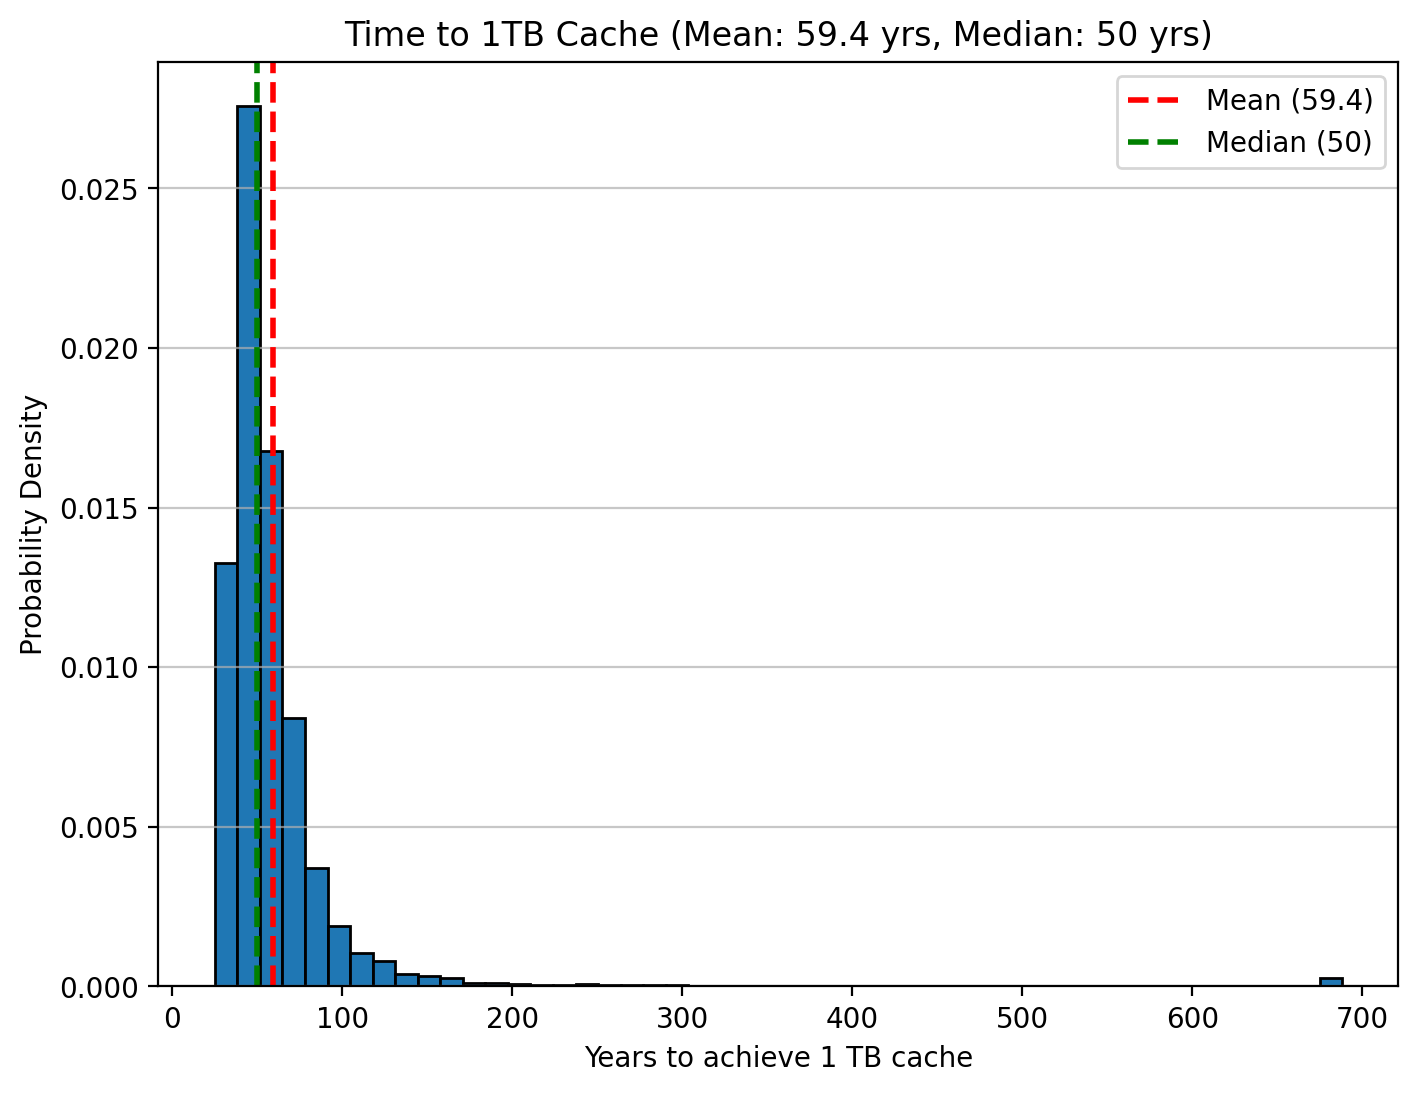

In [19]:
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

# Set matplotlib rcParams
plt.rcParams['figure.dpi'] = 200


def vectorized_monte_carlo(num_simulations: int,
                             current_cache: float,
                             target_cache: float,
                             growth_mean: float,
                             growth_std_dev: float) -> np.ndarray:
    """
    Perform a vectorized Monte Carlo simulation on the GPU.

    All simulations run in parallel.
    """

    # Create parallel arrays for all simulations on the GPU
    # cp.full creates an array of 'num_simulations' elements, all set to 'current_cache'
    caches = cp.full(num_simulations, current_cache, dtype=cp.float64)

    # Track the years for each simulation independently
    years = cp.zeros(num_simulations, dtype=cp.int32)

    # --- This is the key Monte Carlo step ---
    # Sample a different growth rate for each of the 10,000 simulations
    # from a normal distribution.
    sim_growth_rates = cp.random.normal(loc=growth_mean,
                                        scale=growth_std_dev,
                                        size=num_simulations)

    # A sanity check: let's assume growth can't be negative or absurdly low
    cp.maximum(0.01, sim_growth_rates, out=sim_growth_rates)

    # A boolean mask to track which simulations are still running
    # Initially, all are active.
    active_simulations = (caches < target_cache)

    # Run one year at a time, in parallel, for all 10,000 simulations
    # as long as *any* simulation is still running.
    while cp.any(active_simulations):

        # Only apply growth to the simulations that haven't hit the target yet
        # This is a vectorized operation: caches[active_simulations]
        caches[active_simulations] *= (1 + sim_growth_rates[active_simulations])

        # Only increment the year count for active simulations
        years[active_simulations] += 1

        # Update the mask: find which simulations are *still* below the target
        # This will shrink over time as more simulations finish.
        active_simulations = (caches < target_cache)

    # All simulations are done, return the array of results
    # .get() moves the data from GPU memory back to CPU (system RAM)
    return years.get()


def main() -> None:
    """Main function to run the Monte Carlo simulation and plot the results."""
    # Set random seed for reproducibility
    cp.random.seed(42)

    # Simulation parameters
    num_simulations = 10000
    current_cache_gb = 1.1       # Based on AMD EPYC 9684X
    target_cache_gb = 1024       # 1 TB

    # --- Parameters for the distribution ---
    # Instead of one rate, we give a mean and standard deviation
    growth_mean = 0.15           # 15% average annual growth
    growth_std_dev = 0.05        # 5% standard deviation

    # Run the vectorized Monte Carlo simulation
    years_to_target = vectorized_monte_carlo(num_simulations,
                                             current_cache_gb,
                                             target_cache_gb,
                                             growth_mean,
                                             growth_std_dev)

    # Plot the results
    # Now this will be a real distribution, not a single bar
    plt.hist(years_to_target, bins=50, density=True, edgecolor='black')
    plt.xlabel('Years to achieve 1 TB cache')
    plt.ylabel('Probability Density')

    mean_years = np.mean(years_to_target)
    median_years = np.median(years_to_target)

    plt.title(f'Time to 1TB Cache (Mean: {mean_years:.1f} yrs, Median: {median_years:.0f} yrs)')
    plt.axvline(mean_years, color='red', linestyle='dashed', linewidth=2, label=f'Mean ({mean_years:.1f})')
    plt.axvline(median_years, color='green', linestyle='dashed', linewidth=2, label=f'Median ({median_years:.0f})')
    plt.legend()
    plt.grid(axis='y', alpha=0.7)

    #
    plt.show()


if __name__ == '__main__':
    main()